# From Embeddings to Contextual Embeddings
## Self-Attention and a Tiny Transformer Block

In the previous notebooks you saw:
- **Tokenization**: text → tokens (IDs)
- **Embeddings**: token IDs → dense vectors

In this notebook we go from **embeddings → contextual embeddings** using:
- Scaled dot-product **self-attention**
- **Multi-head attention**
- A simple **Transformer block** (attention + feed-forward + residual + layer norm)

No training here, just a **forward pass** to build intuition about the shapes and operations.

## Setup

We will use **PyTorch** for tensor operations and a tiny custom implementation of attention and a Transformer block.

In [ ]:
import torch

if torch.backends.mps.is_available():
    device = "mps" # On M1/M2/M3 Macs, PyTorch uses Apple’s Metal backend (MPS) to access the GPU.
elif torch.cuda.is_available():
    device = "cuda" # For NVIDIA GPUs
else:
    device = "cpu"

device

## 1. From token IDs to embeddings (quick recap)

In the previous notebooks, we already went from:

```text
text → tokens → token IDs → embeddings
```

Here we'll **simulate** that part with a small vocabulary and random embeddings so we can focus on the **attention block**.

In [ ]:
# Tiny toy vocabulary and sequence
vocab_size = 20        # pretend we have 20 tokens in vocab
d_model = 16           # embedding dimension (usually 256, 512, 768, etc.)
max_seq_len = 8        # max length of sequence

# Random sequence of token IDs (batch_size=1)
batch_size = 1
seq_len = 5
token_ids = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
token_ids

In [ ]:
# Token embedding and positional embedding layers
token_embedding = nn.Embedding(vocab_size, d_model).to(device)
positional_embedding = nn.Embedding(max_seq_len, d_model).to(device)

print("token_embeddings shape:", token_embedding)
print("positional_embeddings shape:", positional_embedding)

# Transformers process all tokens in parallel and don’t know their order, 
# so positional embeddings explicitly encode each token’s position so the model can understand sequence structure.
# Without postional embeddings, both "I love AI" and "AI love I" would have the same representation.


# Get token embeddings
tok_emb = token_embedding(token_ids)  # shape: [batch_size, seq_len, d_model]

# Create positions: [0, 1, ..., seq_len-1]
positions = torch.arange(0, seq_len, device=device).unsqueeze(0)  # [1, seq_len]
pos_emb = positional_embedding(positions)                         # [1, seq_len, d_model]

# Input to the Transformer block: token + positional embeddings
x = tok_emb + pos_emb  # [batch_size, seq_len, d_model]
x.shape

So now we have a tensor `x` of shape:

- **batch_size** × **seq_len** × **d_model**
- here: `1 × 5 × 16`

Next step: **self-attention** turns these embeddings into **contextual embeddings**, where each token can “look at” other tokens in the sequence.

## 2. Scaled Dot-Product Self-Attention (single head)

Self-attention operates using three projections of the input:
- **Q**: Query
- **K**: Key
- **V**: Value

For each token, we compute:
1. Attention scores = `Q · Kᵀ`  (how much each token attends to every other token)
2. Scale by `√d_k` (to keep values in a reasonable range)
3. Apply **softmax** to get attention **weights**
4. Multiply weights with **V** to get a weighted sum → new representation

We'll first implement a **single-head** version to see the shapes clearly.

In [ ]:
import torch
import torch.nn as nn
import math

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute scaled dot-product attention.

    Q (Queries):   shape [batch_size, seq_len, d_k]
    K (Keys):      shape [batch_size, seq_len, d_k]
    V (Values):    shape [batch_size, seq_len, d_k]

    mask (optional):
        Shape: [batch_size, 1, seq_len, seq_len]
        Values:
            0     -> keep token
            -inf  -> block / ignore token

    Returns:
        output:            [batch_size, seq_len, d_k]
        attention_weights: [batch_size, seq_len, seq_len]
    """

    # d_k is the dimensionality of key/query vectors (used for scaling)
    d_k = Q.size(-1)

    # ---- ATTENTION SCORES ----
    # We compute similarity between each Query and all Keys.
    # Matrix multiply:
    #   Q: [batch, seq, d_k]
    #   K^T: [batch, d_k, seq]
    #
    # Result:
    #   scores: [batch, seq, seq]
    #
    # Meaning:
    #   scores[i][t][s] = similarity between token t's query and token s's key
    #   i.e. How strongly token t should pay attention to token s when understanding the sentence.
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # ---- SOFTMAX NORMALIZATION ----
    # Convert similarity scores into probabilities.
    # Softmax is taken along the "keys" axis (last dimension).
    #
    # Now each row sums to 1.
    attn_weights = torch.softmax(scores, dim=-1)

    # ---- WEIGHTED SUM OF VALUES ----
    # Multiply probabilities with the value vectors.
    #
    # Output shape:
    #   [batch, seq, d_k]
    #
    # Interpretation:
    #   Each output token becomes the weighted mixture of all value vectors.
    output = torch.matmul(attn_weights, V)

    return output, attn_weights


# ---------------- SINGLE-HEAD ATTENTION EXAMPLE ---------------- #

# For single-head attention, d_k = d_model
d_k = d_model

# Linear layers to project input embeddings x into Q, K, V spaces.
# Each token embedding is transformed into 3 different representations:
#   - Query   (what am I looking for?)
#   - Key     (what do I contain?)
#   - Value   (information to pass along)
W_q = nn.Linear(d_model, d_k).to(device)
W_k = nn.Linear(d_model, d_k).to(device)
W_v = nn.Linear(d_model, d_k).to(device)

# Apply linear projections to get Q, K, V
# Shapes: [batch_size, seq_len, d_k]
Q = W_q(x)
K = W_k(x)
V = W_v(x)

# Feed them into scaled-dot-product attention
out_single_head, attn_weights = scaled_dot_product_attention(Q, K, V)

# Output shapes:
#   out_single_head: [batch_size, seq_len, d_k]
#   attn_weights:    [batch_size, seq_len, seq_len]
out_single_head.shape, attn_weights.shape


In [ ]:
# Let's inspect the attention weights for the single example in the batch
attn_weights[0].detach().cpu()  # shape: [seq_len, seq_len]

Each row of this matrix tells you: **for one token, how much it attends to every token in the sequence**.

- Values are between 0 and 1
- Rows sum to 1 (because of softmax)

Next, we'll move to **multi-head attention**, which is what real Transformers use.

## 3. Multi-Head Attention

Multi-head attention does the same thing as above, but **multiple times in parallel** with different projections (different Q/K/V for each head):

1. Split `d_model` into `num_heads` smaller dimensions (`d_head = d_model / num_heads`)
2. For each head: compute its own attention
3. Concatenate all heads back into a single vector of size `d_model`

This helps the model attend to **different types of relationships** in parallel (e.g., syntax, long-range dependencies, etc.).

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        # Ensure we can evenly split d_model across heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model          # total embedding dimension
        self.num_heads = num_heads      # number of attention heads
        self.d_head = d_model // num_heads  # dimension per head

        # These linears map the input embeddings into Q, K, V vectors.
        # Note: they output d_model dims, which we later split into heads.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # After attention across heads, we recombine and project back to d_model
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        # x shape: [batch_size, seq_len, d_model]
        batch_size, seq_len, _ = x.size()

        # ---- PROJECT INPUT INTO Q, K, V ----
        # Each becomes [batch_size, seq_len, d_model]
        # Then reshape into [batch_size, seq_len, num_heads, d_head]
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_head)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_head)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_head)

        # ---- REARRANGE TO PUT HEADS BEFORE SEQ LEN ----
        # New shape: [batch_size, num_heads, seq_len, d_head]
        # This makes it easier to compute attention per head
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # ---- SCALED DOT-PRODUCT ATTENTION PER HEAD ----
        d_k = self.d_head  # scaling factor (dimension of each head)

        # scores: [batch, heads, seq_len, seq_len]
        # For each head, compare every token's query to every token's key
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        # Optional mask (for padding or causal attention)
        if mask is not None:
            # mask should be broadcastable to scores' shape
            scores = scores + mask

        # Convert similarity scores → attention probabilities
        attn_weights = torch.softmax(scores, dim=-1)  # [b, h, seq_len, seq_len]

        # Weighted sum of value vectors using attention weights
        # Result per head: [batch, heads, seq_len, d_head]
        context = torch.matmul(attn_weights, V)

        # ---- REARRANGE BACK ----
        # Move seq_len before num_heads: [batch, seq_len, heads, d_head]
        context = context.transpose(1, 2).contiguous()

        # ---- CONCATENATE ALL HEADS ----
        # Flatten heads into a single vector per token:
        # [batch, seq_len, heads * d_head] = [batch, seq_len, d_model]
        context = context.view(batch_size, seq_len, self.d_model)

        # ---- FINAL LINEAR PROJECTION ----
        # Mix information across heads
        out = self.W_o(context)

        # Return:
        # out:         [batch, seq_len, d_model]
        # attn_weights:[batch, heads, seq_len, seq_len]
        return out, attn_weights


# Example usage
num_heads = 4
mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads).to(device)

# Forward pass through multi-head attention
mha_out, mha_attn = mha(x)

# Shapes:
# mha_out  -> [1, seq_len, d_model]
# mha_attn -> [1, num_heads, seq_len, seq_len]
mha_out.shape, mha_attn.shape

In [ ]:
# Look at attention weights for head 0
mha_attn[0, 0].detach().cpu()  # [seq_len, seq_len]

Now for each head we have its own attention pattern over the sequence.

Next we'll wrap this into a **Transformer block** that adds residual connections, layer normalization, and a feed-forward network.

## 4. A Tiny Transformer Block

A standard Transformer encoder block does:

1. **Multi-head self-attention** + residual + layer norm
2. **Feed-forward network (FFN)** + residual + layer norm

Diagram (rough):

```text
x → MultiHeadSelfAttention → + x → LayerNorm → FFN → + (previous) → LayerNorm
```

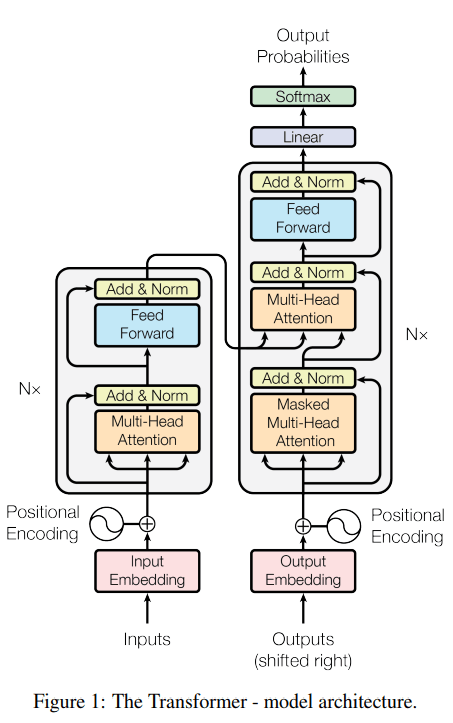

Let's implement a simple version.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)

        # Feed-forward network
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Self-attention block
        attn_out, attn_weights = self.mha(x, mask=mask)
        x = self.norm1(x + attn_out)  # residual + norm

        # Feed-forward block
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)    # residual + norm

        return x, attn_weights


block = TransformerBlock(d_model=d_model, num_heads=num_heads, d_ff=64).to(device)
contextual_embeddings, attn_weights_block = block(x)
contextual_embeddings.shape

In [ ]:
# Compare input embeddings vs contextual embeddings for the first token
print("Original first token embedding:")
print(x[0, 0].detach().cpu())

print("\nContextual first token embedding (after Transformer block):")
print(contextual_embeddings[0, 0].detach().cpu())

Even though we haven't trained anything, you can see that the representation of each token **changes** after going through the Transformer block.

Conceptually:
- **Input embeddings**: mostly local to each token
- **Contextual embeddings**: mix information from other tokens via attention

In a **real LLM**, many such layers are stacked, trained on massive text data, and the final contextual embeddings are used to predict **logits** for the next token.

## 5. Where this notebook fits in the full LLM pipeline

Overall pipeline:

```text
Text → Tokenization → Token IDs
     → Embeddings (token + position)
     → Transformer blocks (self-attention + FFN)  ← (THIS notebook)
     → Final hidden state → Logits → Decoding → Detokenization → Output text
```

**You already covered:**
- Tokenization
- Embeddings

**This notebook covered:**
- Self-attention (single-head and multi-head)
- A simple Transformer encoder block

**Possible next notebooks:**
1. **From contextual embeddings to logits and probabilities** (linear output layer + softmax)
2. **Decoding strategies**: greedy, top-k, top-p (showing how different strategies change the generated text)
3. **Masking**: causal masks for autoregressive generation (why the model can’t look into the future)

You can reuse this block and extend it to build towards a **tiny language model forward pass** in the next class.